# งานที่ 2: Thai Food Image Classification Using Computer Vision

**Objective:** จำแนกภาพอาหารไทย 5 ประเภทด้วย MobileNetV2 Transfer Learning
อินพุตคือภาพ RGB เอาต์พุตคือประเภทอาหารและ Confidence

| Class label | ชื่ออาหารไทย |
|---|---|
| `tom_yum` | ต้มยำ |
| `som_tam` | ส้มตำ |
| `noodle` | ก๋วยเตี๋ยว |
| `larb` | ลาบ |
| `pad_kra_pao` | ผัดกะเพรา |

**Workflow:** ตรวจ Dataset → Preprocessing/Augmentation → สร้างและฝึกโมเดล → ประเมิน Test → สาธิตภาพใหม่
มีผลการทดลองที่บันทึกไว้แล้ว ดู **Final Results Summary** ท้าย Notebook
สำหรับนำเสนอหลัง Restart Kernel ให้รัน **Presentation Mode** เท่านั้น ไม่กด Run All เพราะจะฝึกและเขียน checkpoint ใหม่


## Dataset Preparation / Dataset Inspection — ตรวจสอบและสำรวจข้อมูล

ภาพต้นฉบับอยู่ใน `thai_food_raw/<class>/`; `dataset_prepare.py` ตรวจภาพเสีย แก้ EXIF
แปลง RGB/JPEG และตรวจภาพซ้ำก่อนแบ่งต่อคลาสประมาณ **70/15/15** ด้วย seed 42
ภาพใช้งานอยู่ใน `thai_food/<split>/<class>/` รวม 646 ภาพ: Train 452 / Validation 99 / Test 95
เซลล์ด้านล่างตรวจโฟลเดอร์ทั้ง 5 คลาสและภาพที่อ่านได้; `.gitkeep` ไม่นับเป็นรูป

Train ใช้เรียนรู้ weights, Validation ใช้ EarlyStopping/เลือก checkpoint และ Test ใช้ประเมินหลังเลือกโมเดล
ภาพซ้ำ ภาพใกล้เคียง หรือภาพจากอาหารจานเดียวกันควรอยู่ split เดียวกัน


In [1]:
from pathlib import Path
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image, ImageOps, UnidentifiedImageError
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ใช้ฟอนต์ภาษาไทยที่มีอยู่บนเครื่อง โดยไม่ดาวน์โหลดเพิ่ม
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
thai_font = next((name for name in ["Tahoma", "Noto Sans Thai", "Leelawadee UI", "Th Sarabun New"]
                  if name in installed_fonts), None)
if thai_font:
    plt.rcParams["font.family"] = thai_font
plt.rcParams["axes.unicode_minus"] = False

# ลำดับคลาสและชื่ออาหารใช้ร่วมกับ Demo โดยไม่โหลดหรือฝึกโมเดล
from task2_food_demo import class_names, thai_labels, english_labels

splits = ["train", "val", "test"]
DATA_DIR = Path("thai_food")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

print("Current working directory:", Path.cwd())
print("พบ thai_food:", DATA_DIR.is_dir())
print("กรุณาเปิด Notebook จากโฟลเดอร์โปรเจกต์ที่มี thai_food อยู่")


Current working directory: d:\campus-recruitment
พบ thai_food: True
กรุณาเปิด Notebook จากโฟลเดอร์โปรเจกต์ที่มี thai_food อยู่


In [2]:
image_files = {}
rows = []
missing_folders = []
unexpected_folders = []
invalid_images = []

for split in splits:
    split_dir = DATA_DIR / split
    if not split_dir.is_dir():
        missing_folders.append(str(split_dir))
    else:
        unexpected_folders.extend(str(p) for p in split_dir.iterdir()
                                  if p.is_dir() and p.name not in class_names)
    for name in class_names:
        folder = split_dir / name
        if not folder.is_dir():
            missing_folders.append(str(folder))
        files = sorted(p for p in folder.rglob("*")
                       if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
        readable = []
        for path in files:
            try:
                with Image.open(path) as img:
                    img.verify()
                with Image.open(path) as img:
                    img.convert("RGB").load()
                readable.append(path)
            except (OSError, ValueError, UnidentifiedImageError, Image.DecompressionBombError) as exc:
                invalid_images.append({"file": str(path), "reason": str(exc)})
        image_files[(split, name)] = readable
        rows.append({"split": split, "class": name, "Thai name": thai_labels[name],
                     "image files": len(files), "readable images": len(readable)})

count_df = pd.DataFrame(rows)
counts = count_df.pivot(index="class", columns="split", values="readable images")
counts = counts.reindex(index=class_names, columns=splits).fillna(0).astype(int)
display(count_df)

if missing_folders:
    print("โฟลเดอร์ที่ขาด:", missing_folders)
if unexpected_folders:
    print("โฟลเดอร์คลาสที่ไม่คาดหมาย (ย้ายออกก่อนฝึก):", unexpected_folders)
if invalid_images:
    print("รูปที่เปิดไม่ได้ (แก้ไขหรือย้ายออกก่อนฝึก):")
    display(pd.DataFrame(invalid_images))

dataset_ready = (not missing_folders and not unexpected_folders
                 and not invalid_images and bool((counts.to_numpy() > 0).all()))
if dataset_ready:
    print("มีภาพที่อ่านได้ครบทุกคลาสในทุก split — ตรวจภาพซ้ำต่อไป")
else:
    print("ยังไม่พร้อมฝึก: เติมรูปจริงอย่างน้อย 1 รูปในแต่ละคลาสของทั้ง 3 split")
    print("แนะนำรวม 100–200 รูปต่อคลาส แบ่ง 70/15/15 และแก้ปัญหาที่รายงานด้านบน")


,split,class,Thai name,image files,readable images
0,train,tom_yum,ต้มยำ,76,76
1,train,som_tam,ส้มตำ,90,90
2,train,noodle,ก๋วยเตี๋ยว,89,89
3,train,larb,ลาบ,110,110
4,train,pad_kra_pao,ผัดกะเพรา,87,87
5,val,tom_yum,ต้มยำ,17,17
6,val,som_tam,ส้มตำ,20,20
7,val,noodle,ก๋วยเตี๋ยว,19,19
8,val,larb,ลาบ,24,24
9,val,pad_kra_pao,ผัดกะเพรา,19,19


มีภาพที่อ่านได้ครบทุกคลาสในทุก split — ตรวจภาพซ้ำต่อไป


### ตรวจภาพซ้ำข้าม split (Data leakage check)
Notebook ตรวจ SHA-256 ของไฟล์ซ้ำข้าม split และระงับการฝึกหากพบ โดยไม่ลบหรือย้ายภาพเอง
วิธีนี้ไม่ครอบคลุมภาพ crop/resize/บีบอัดใหม่ทั้งหมด จึงต้องใช้การตรวจของ preparation และตรวจด้วยคนประกอบ


In [3]:
seen_hashes = {}
duplicate_rows = []
for (split, name), files in image_files.items():
    for path in files:
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        for previous_split, previous_path in seen_hashes.get(digest, []):
            if previous_split != split:
                duplicate_rows.append({"first image": str(previous_path), "first split": previous_split,
                                       "duplicate image": str(path), "duplicate split": split})
        seen_hashes.setdefault(digest, []).append((split, path))

if duplicate_rows:
    dataset_ready = False
    print("พบภาพซ้ำข้าม split: กรุณาจัดข้อมูลใหม่ก่อนฝึก เพื่อป้องกัน Data leakage")
    display(pd.DataFrame(duplicate_rows))
elif count_df["readable images"].sum() > 0:
    print("ไม่พบไฟล์ที่เหมือนกันทุกไบต์ข้าม split; ยังต้องตรวจ near-duplicates ด้วยคน")
else:
    print("ยังไม่มีรูปสำหรับตรวจภาพซ้ำ")


ไม่พบไฟล์ที่เหมือนกันทุกไบต์ข้าม split; ยังต้องตรวจ near-duplicates ด้วยคน


### แหล่งข้อมูล

ภาพต้นฉบับรวบรวมไว้ใน `thai_food_raw/<class>/` แต่ `sources.csv` และ `food_image_urls.example.csv`
มีเฉพาะหัวตาราง จึงยังยืนยัน URL เว็บไซต์ ผู้ถ่าย หรือใบอนุญาตต้นฉบับไม่ได้ ไม่อ้างว่าเป็นภาพจาก Kaggle
การมี download helper ไม่ยืนยันว่าภาพชุดนี้ถูกดาวน์โหลดด้วย helper; หากมีหลักฐานให้เติมข้อมูลจริงใน `sources.csv`

การรีวิวพบ 646 ภาพตรงกับ manifest และไม่พบภาพซ้ำข้าม split จาก SHA-256 ของไฟล์/พิกเซล
และ dHash ตามเกณฑ์ของ preparation แต่ภาพคนละมุมของจานเดียวกันยังต้องตรวจด้วยคน


### Class distribution (EDA)
ดูจำนวนภาพแต่ละคลาสและ split เพื่อประเมิน Class imbalance ประกอบกับ Recall/F1 รายคลาส


,images,percent
split,,
train,452,70.0
val,99,15.3
test,95,14.7


split,train,val,test,total
class,,,,
tom_yum,76,17,16,109
som_tam,90,20,19,129
noodle,89,19,19,127
larb,110,24,23,157
pad_kra_pao,87,19,18,124


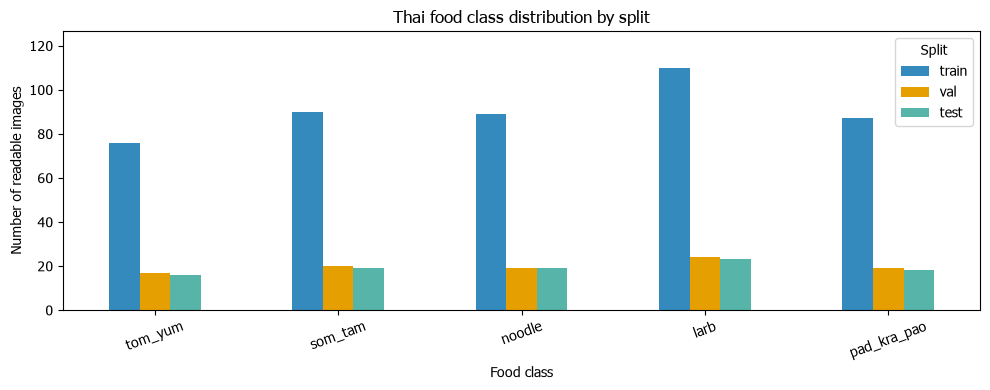

train: largest/smallest = 1.45 — จำนวนแต่ละคลาสใกล้เคียงกัน
val: largest/smallest = 1.41 — จำนวนแต่ละคลาสใกล้เคียงกัน
test: largest/smallest = 1.44 — จำนวนแต่ละคลาสใกล้เคียงกัน
เกณฑ์ 1.5 เป็นเพียงแนวทางเบื้องต้น; ควรดู Recall และ F1 รายคลาสหลังฝึกด้วย


In [4]:
split_totals = counts.sum(axis=0)
display(pd.DataFrame({"images": split_totals,
                      "percent": (split_totals / max(int(split_totals.sum()), 1) * 100).round(1)}))
distribution = counts.copy()
distribution["total"] = distribution.sum(axis=1)
display(distribution)

ax = counts.plot.bar(figsize=(10, 4), color=["#348ABD", "#E69F00", "#56B4A9"])
ax.set_title("Thai food class distribution by split")
ax.set_xlabel("Food class")
ax.set_ylabel("Number of readable images")
ax.set_ylim(0, max(1, int(counts.to_numpy().max()) * 1.15))
if counts.to_numpy().sum() == 0:
    ax.text(0.5, 0.5, "No images yet — add real food photos",
            transform=ax.transAxes, ha="center", va="center")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Split")
plt.tight_layout()
plt.show()

for split in splits:
    values = counts[split]
    if values.sum() == 0:
        print(f"{split}: ยังไม่มีรูป")
    elif values.min() == 0:
        print(f"{split}: มีคลาสที่ไม่มีรูป ควรเติมข้อมูลให้ครบ")
    else:
        ratio = values.max() / values.min()
        note = "อาจมี Class imbalance ควรเพิ่มรูปคลาสที่มีน้อย" if ratio >= 1.5 else "จำนวนแต่ละคลาสใกล้เคียงกัน"
        print(f"{split}: largest/smallest = {ratio:.2f} — {note}")
print("เกณฑ์ 1.5 เป็นเพียงแนวทางเบื้องต้น; ควรดู Recall และ F1 รายคลาสหลังฝึกด้วย")


### ตัวอย่างภาพอาหาร
แสดงสูงสุด 2 ภาพต่อคลาสจาก **Train เท่านั้น** พร้อมชื่อคลาสและชื่อไทย


tom_yum = ต้มยำ: 76 training images
som_tam = ส้มตำ: 90 training images
noodle = ก๋วยเตี๋ยว: 89 training images
larb = ลาบ: 110 training images
pad_kra_pao = ผัดกะเพรา: 87 training images


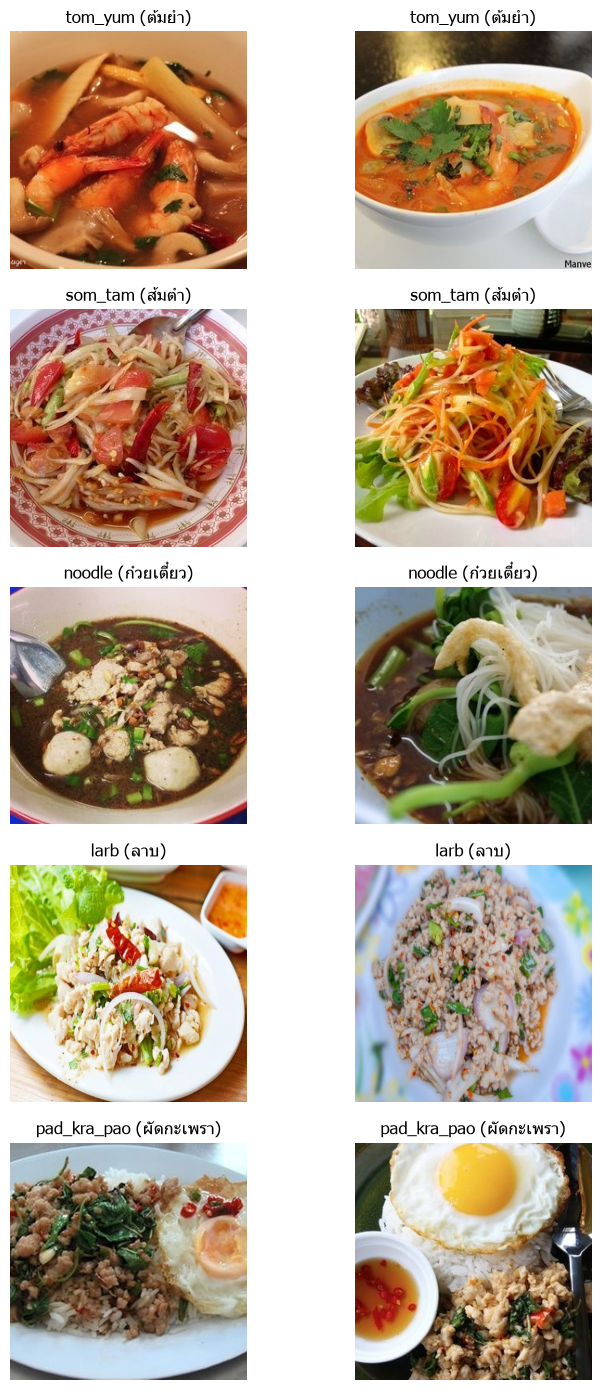

In [5]:
rng = random.Random(SEED)
fig, axes = plt.subplots(len(class_names), 2, figsize=(8, 14))
for row, name in enumerate(class_names):
    files = image_files[("train", name)]
    samples = rng.sample(files, min(2, len(files)))
    for col in range(2):
        ax = axes[row, col]
        ax.axis("off")
        if col < len(samples):
            with Image.open(samples[col]) as img:
                ax.imshow(ImageOps.exif_transpose(img).convert("RGB"))
        else:
            ax.text(0.5, 0.5, "No training image yet", ha="center", va="center")
        title = f"{name} ({thai_labels[name]})" if thai_font else name
        ax.set_title(title)
    print(f"{name} = {thai_labels[name]}: {len(files)} training images")
plt.tight_layout()
plt.show()


## Image Preprocessing and Data Augmentation

ใช้ RGB **224×224**, Bilinear resize และ Batch size **16**
Data loader ส่งพิกเซลดิบ `[0,255]` เข้าโมเดล ซึ่งทำ Augmentation แล้วเรียก MobileNetV2 `preprocess_input`
**ครั้งเดียว** เพื่อแปลงเป็น `[-1,1]`; ห้ามหาร 255 หรือ normalize ซ้ำที่ prediction
กำหนด `class_names` คงที่ทุก split และ shuffle เฉพาะ Train เพื่อให้ Labels ตรงกับ Predictions

อ้างอิง: [Keras image loading](https://keras.io/api/data_loading/image/),
[MobileNetV2 preprocessing](https://www.tensorflow.org/api_docs/python/tf/keras/applications/mobilenet_v2/preprocess_input)


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
tf = None
train_ds = val_ds = test_ds = None
pipeline_ready = False

if dataset_ready:
    try:
        import tensorflow as tf
        tf.keras.utils.set_random_seed(SEED)
        tf.config.experimental.enable_op_determinism()
        print("TensorFlow:", tf.__version__)
        print("GPU devices:", tf.config.list_physical_devices("GPU"))
        print("หากไม่มี GPU จะใช้ CPU อัตโนมัติ")

        datasets = {}
        for split in splits:
            datasets[split] = tf.keras.utils.image_dataset_from_directory(
                DATA_DIR / split,
                labels="inferred",
                label_mode="int",
                class_names=class_names,
                color_mode="rgb",
                image_size=IMG_SIZE,
                interpolation="bilinear",
                batch_size=BATCH_SIZE,
                shuffle=(split == "train"),
                seed=SEED,
            ).prefetch(1)
        train_ds, val_ds, test_ds = (datasets[s] for s in splits)
        pipeline_ready = True
        print("Class index mapping:", dict(enumerate(class_names)))
    except (ImportError, OSError, ValueError) as exc:
        print("ยังเตรียม pipeline ไม่สำเร็จ:", exc)
        print("ตรวจภาพและติดตั้ง requirements.txt ใน Python kernel นี้ แล้ว Restart → Run All")
else:
    print("ข้าม Image Preprocessing: Dataset ยังไม่พร้อม กรุณาดูขั้นที่ 0")


TensorFlow: 2.21.0
GPU devices: []
หากไม่มี GPU จะใช้ CPU อัตโนมัติ
Found 452 files belonging to 5 classes.
Found 99 files belonging to 5 classes.
Found 95 files belonging to 5 classes.
Class index mapping: {0: 'tom_yum', 1: 'som_tam', 2: 'noodle', 3: 'larb', 4: 'pad_kra_pao'}


### Data Augmentation
ใช้ RandomFlip (horizontal), RandomRotation, RandomZoom และ RandomContrast ระดับเล็กน้อยภายในโมเดล
เปิดใช้เฉพาะการฝึก; Validation/Test/prediction ใช้ inference mode ตัวอย่างด้านล่างมาจาก Train


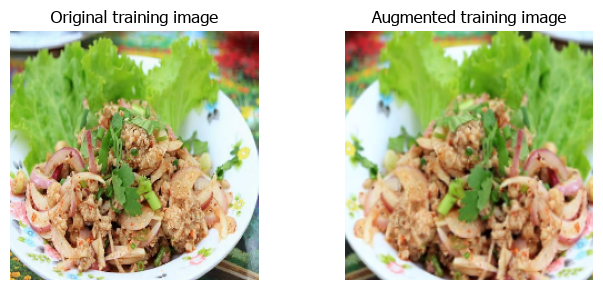

In [7]:
data_augmentation = None
if pipeline_ready:
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.05, fill_mode="reflect", seed=SEED + 1),
        tf.keras.layers.RandomZoom(0.10, fill_mode="reflect", seed=SEED + 2),
        tf.keras.layers.RandomContrast(0.10, seed=SEED + 3),
    ], name="food_augmentation")

    sample_batch, _ = next(iter(train_ds))
    augmented_batch = data_augmentation(sample_batch, training=True)
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    for ax, image, title in zip(axes, [sample_batch[0], augmented_batch[0]],
                               ["Original training image", "Augmented training image"]):
        ax.imshow(np.clip(image.numpy(), 0, 255).astype("uint8"))
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("ข้าม Data Augmentation: ต้องมี Dataset ที่พร้อมก่อน")


## Model Architecture — MobileNetV2 Transfer Learning
**Transfer Learning** คือใช้โมเดลที่เคยเรียนรู้ลักษณะภาพจาก **ImageNet** แล้ว
มาเป็นตัวสกัด Features ของรูปอาหาร จากนั้นฝึกชั้นจำแนกประเภทใหม่สำหรับ 5 คลาสนี้
MobileNetV2 มีขนาดเบา ทำงานเร็ว และมี Pretrained weights จึงเหมาะกับข้อมูลขนาดเล็กและเครื่องนักศึกษา

**Base Transfer Learning:** ตั้ง `include_top=False`, `weights="imagenet"` และ Freeze base model
ต่อด้วย `GlobalAveragePooling2D → Dropout(0.3) → Dense(5, softmax)`
เรียก base ด้วย `training=False` เพื่อรักษาสถิติ BatchNormalization เดิม
Preprocessing อยู่ใน Functional model และบันทึกไปกับไฟล์ `.keras` จึงโหลดกลับได้โดยไม่ต้องมี custom layer

ครั้งแรกที่มีข้อมูลพร้อม Keras อาจต้องดาวน์โหลด **ImageNet weights** (ไม่ใช่รูปอาหาร)
จึงต้องใช้อินเทอร์เน็ตครั้งแรก ถ้าโหลดไม่ได้จะรายงานและข้ามการฝึก


In [8]:
model = base_model = None
if pipeline_ready:
    try:
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet"
        )
        base_model.trainable = False

        inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), dtype="float32", name="raw_rgb_image")
        x = data_augmentation(inputs)
        # แปลงพิกเซลเพียงครั้งเดียว; ห้ามหาร 255 เพิ่มที่ dataset หรือ predict_food
        x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
        x = base_model(x, training=False)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dropout(0.3, seed=SEED + 4)(x)
        outputs = tf.keras.layers.Dense(len(class_names), activation="softmax", name="food_class")(x)
        model = tf.keras.Model(inputs, outputs, name="thai_food_mobilenet_v2")
        model.summary()
    except Exception as exc:  # Keras get_file อาจรายงานการดาวน์โหลดล้มเหลวเป็น Exception ทั่วไป
        model = None
        print("ยังสร้างโมเดลไม่ได้:", exc)
        print("ตรวจอินเทอร์เน็ตสำหรับ ImageNet weights แล้วรันขั้นนี้ใหม่")
else:
    print("ข้ามการสร้างโมเดล: ยังไม่มี Dataset ที่พร้อม")


Model: "thai_food_mobilenet_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_rgb_image (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ food_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ food_class (Dense)              │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Training

Compile ด้วย Adam (`learning_rate=0.001`), SparseCategoricalCrossentropy (`from_logits=False`)
สำหรับ Labels 0–4 และ Softmax outputs ติดตาม Accuracy
ฝึกไม่เกิน **10 Epochs**, Batch size 16; EarlyStopping ดู `val_loss`, patience 3 และคืน weights ที่ดีที่สุด
ModelCheckpoint บันทึก `thai_food_model.keras` เมื่อ Validation loss ดีขึ้น แล้วโหลด checkpoint ที่ดีที่สุด
Test ไม่ถูกใช้ในขั้นนี้

**ส่วนนี้เป็นหลักฐานการฝึก ไม่ต้องรันระหว่างนำเสนอ:** รันใหม่จะฝึกและเขียน checkpoint ชื่อเดิม


In [9]:
model_compiled = False
if model is not None:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )
    model_compiled = True
    print("Compile สำเร็จ: Adam / SparseCategoricalCrossentropy / accuracy")
else:
    print("ข้าม Compile: ยังไม่มีโมเดล")


Compile สำเร็จ: Adam / SparseCategoricalCrossentropy / accuracy


In [10]:
EPOCHS = 10
MODEL_PATH = Path("thai_food_model.keras")
history = None
best_model = None

if model_compiled and pipeline_ready:
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(str(MODEL_PATH), monitor="val_loss", save_best_only=True),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
    best_model = tf.keras.models.load_model(MODEL_PATH)
    print("โหลด Base Transfer Learning checkpoint ที่ดีที่สุด:", MODEL_PATH)
else:
    print("ยังไม่ฝึก: เติมภาพจริงและแก้ปัญหาในขั้นที่ 0–6 แล้ว Restart → Run All")


Epoch 1/10


C:\Users\kripz\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.4049 - loss: 1.4956 - val_accuracy: 0.7475 - val_loss: 0.8768
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.7478 - loss: 0.7490 - val_accuracy: 0.8788 - val_loss: 0.5165
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.8341 - loss: 0.5100 - val_accuracy: 0.8990 - val_loss: 0.3982
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.8805 - loss: 0.3884 - val_accuracy: 0.9091 - val_loss: 0.3489
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.9115 - loss: 0.3142 - val_accuracy: 0.8687 - val_loss: 0.3422
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - accuracy: 0.9137 - loss: 0.2892 - val_accuracy: 0.8990 - val_loss: 0.3511
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9226 - loss: 0.2577 - val_accuracy: 0.9394 - val_loss: 0.2789
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.9314 - loss: 0.2376 - val_accuracy: 0.8889 - val

## Training Results — Accuracy / Loss
กราฟจาก history ที่บันทึกในการฝึกจริง: Accuracy ควรเพิ่มและ Loss ควรลด
หาก Train ดีขึ้นแต่ Validation แย่ลง อาจเกิด Overfitting; ถ้าทั้งสองชุดยังไม่ดีอาจเกิด Underfitting


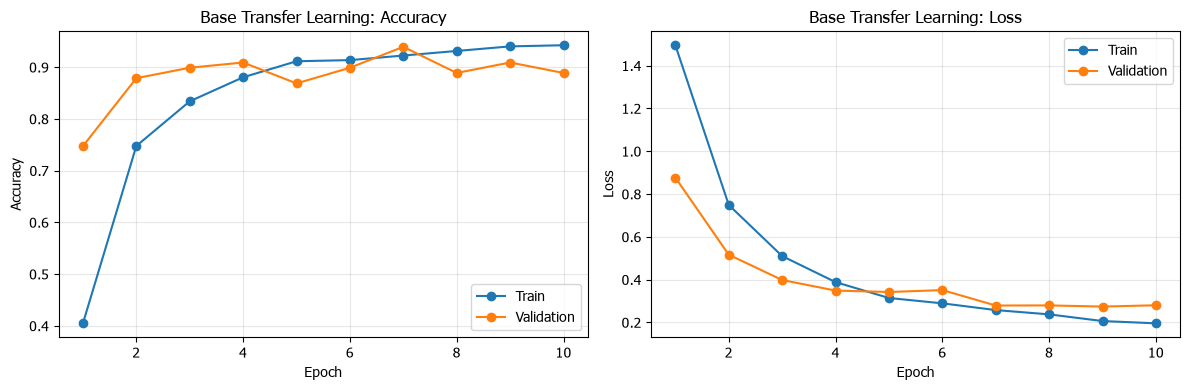

In [11]:
def plot_training_history(training_history, title="Base Transfer Learning"):
    if training_history is None:
        print("ยังไม่มี Training history — ต้องฝึกกับภาพจริงก่อน")
        return
    values = training_history.history
    epochs_ran = range(1, len(values["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, label in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
        ax.plot(epochs_ran, values[metric], marker="o", label="Train")
        ax.plot(epochs_ran, values[f"val_{metric}"], marker="o", label="Validation")
        ax.set_title(f"{title}: {label}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(label)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_training_history(history)


### Optional Fine-Tuning — ไม่ได้ใช้ในการทดลองนี้
เก็บโค้ดทางเลือกเดิมไว้ ค่า `RUN_FINE_TUNING=False` จึงใช้ Base checkpoint เป็นโมเดลสุดท้าย
หากเปิดในอนาคต จะฝึกเฉพาะ layers ท้ายที่ไม่ใช่ BatchNormalization และเลือกด้วย Validation loss
ไม่ต้องรันหรือเปิดตัวเลือกนี้ระหว่างนำเสนอ


In [12]:
RUN_FINE_TUNING = False
FINE_TUNE_EPOCHS = 3
FINE_TUNE_PATH = Path("thai_food_model_finetuned.keras")
fine_history = None
final_model = best_model
selected_model_name = "Base Transfer Learning"

if RUN_FINE_TUNING and best_model is not None:
    fine_model = tf.keras.models.load_model(MODEL_PATH)
    fine_base = fine_model.get_layer(base_model.name)
    fine_base.trainable = True
    for layer in fine_base.layers[:-20]:
        layer.trainable = False
    for layer in fine_base.layers[-20:]:
        layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)
    fine_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    fine_history = fine_model.fit(
        train_ds, validation_data=val_ds, epochs=FINE_TUNE_EPOCHS,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(str(FINE_TUNE_PATH), monitor="val_loss", save_best_only=True),
        ],
    )
    fine_model = tf.keras.models.load_model(FINE_TUNE_PATH)
    base_val = best_model.evaluate(val_ds, verbose=0, return_dict=True)
    fine_val = fine_model.evaluate(val_ds, verbose=0, return_dict=True)
    display(pd.DataFrame([base_val, fine_val], index=["Base", "Fine-Tuned"]))
    plot_training_history(fine_history, title="Optional Fine-Tuning")
    if fine_val["loss"] < base_val["loss"]:
        final_model = fine_model
        selected_model_name = "Optional Fine-Tuning"
    print("เลือกด้วย Validation loss:", selected_model_name)
elif RUN_FINE_TUNING:
    print("ยัง Fine-Tune ไม่ได้: ต้องฝึก Base กับภาพจริงก่อน")
else:
    print("ข้าม Optional Fine-Tuning (RUN_FINE_TUNING=False)")


ข้าม Optional Fine-Tuning (RUN_FINE_TUNING=False)


## Test Model
ประเมิน Test Loss และ Test Accuracy ของโมเดลที่เลือกด้วย Validation แล้ว
ผลด้านล่างเป็นการประเมินที่บันทึกไว้ ไม่ต้องรันซ้ำระหว่างนำเสนอ


In [13]:
test_results = None
if final_model is not None and test_ds is not None:
    print("โมเดลสุดท้าย:", selected_model_name)
    test_results = final_model.evaluate(test_ds, verbose=1, return_dict=True)
    print(f"Test Loss: {test_results['loss']:.4f}")
    print(f"Test Accuracy: {test_results['accuracy']:.4f}")
else:
    print("ยังไม่มีผล Test: ต้องมีโมเดลที่ฝึกแล้วและภาพ Test จริงก่อน")


โมเดลสุดท้าย: Base Transfer Learning
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.9053 - loss: 0.2806
Test Loss: 0.2806
Test Accuracy: 0.9053


## Evaluation — Classification Metrics

- **Accuracy:** สัดส่วนภาพทั้งหมดที่ทำนายถูก
- **Precision:** เมื่อทำนายเป็นคลาสหนึ่ง มีสัดส่วนถูกจริงเท่าใด
- **Recall:** จากภาพจริงของคลาสนั้น โมเดลค้นพบถูกเท่าใด
- **F1-Score:** ค่าเฉลี่ยแบบ Harmonic mean ของ Precision และ Recall

รายงานภาพรวมแบบ **Macro average** ให้น้ำหนักเท่ากันทุกคลาส และรายงานแยกครบทั้ง 5 คลาส
`zero_division=0` จัดการคลาสที่ไม่ถูกทำนายเลยอย่างชัดเจน
เก็บ Labels และคำทำนายใน loop เดียวกันจาก Test ที่ไม่ shuffle เพื่อไม่ให้ลำดับเหลื่อม

Weighted average ใน Report ถ่วงน้ำหนักตามจำนวนภาพของแต่ละคลาส


In [14]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

y_true = y_pred = None
if final_model is not None and test_ds is not None:
    actual_batches, predicted_batches = [], []
    for images, labels in test_ds:
        probabilities = final_model.predict_on_batch(images)
        actual_batches.append(labels.numpy())
        predicted_batches.append(np.argmax(probabilities, axis=1))
    y_true = np.concatenate(actual_batches)
    y_pred = np.concatenate(predicted_batches)
    label_indices = np.arange(len(class_names))
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_indices, average="macro", zero_division=0
    )
    display(pd.DataFrame([{
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision, "Recall (macro)": recall, "F1-Score (macro)": f1,
    }]))
    print(classification_report(y_true, y_pred, labels=label_indices,
                                target_names=class_names, zero_division=0, digits=4))
    display(pd.DataFrame({"Class": class_names, "ชื่อไทย": [thai_labels[n] for n in class_names]}))
else:
    print("ยังคำนวณ Accuracy / Precision / Recall / F1-Score ไม่ได้: ไม่มีผลทำนาย Test จริง")


,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,0.905263,0.925287,0.902924,0.906799


              precision    recall  f1-score   support

     tom_yum     0.8889    1.0000    0.9412        16
     som_tam     0.9444    0.8947    0.9189        19
      noodle     1.0000    0.8421    0.9143        19
        larb     0.7931    1.0000    0.8846        23
 pad_kra_pao     1.0000    0.7778    0.8750        18

    accuracy                         0.9053        95
   macro avg     0.9253    0.9029    0.9068        95
weighted avg     0.9201    0.9053    0.9051        95



,Class,ชื่อไทย
0,tom_yum,ต้มยำ
1,som_tam,ส้มตำ
2,noodle,ก๋วยเตี๋ยว
3,larb,ลาบ
4,pad_kra_pao,ผัดกะเพรา


### Confusion Matrix
แกนตั้ง = Actual class, แกนนอน = Predicted class แนวทแยงคือภาพที่ทำนายถูก
ผลที่บันทึกไว้มีคู่ผิดมากที่สุดคือผัดกะเพรา → ลาบ 4 ภาพ; ดูผลรายคลาสประกอบ Accuracy


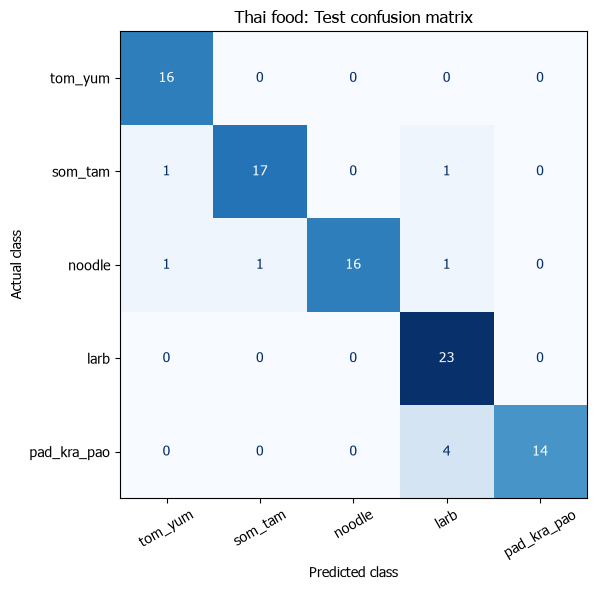

คู่ที่ผิดมากที่สุดหนึ่งคู่: จริง pad_kra_pao → ทำนาย larb
จำนวน: 4


In [15]:
if y_true is not None and y_pred is not None:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", values_format="d", xticks_rotation=30, colorbar=False
    )
    ax.set_title("Thai food: Test confusion matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    plt.tight_layout()
    plt.show()

    off_diagonal = cm.copy()
    np.fill_diagonal(off_diagonal, 0)
    if off_diagonal.max() > 0:
        actual, predicted = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
        print(f"คู่ที่ผิดมากที่สุดหนึ่งคู่: จริง {class_names[actual]} → ทำนาย {class_names[predicted]}")
        print("จำนวน:", int(off_diagonal[actual, predicted]))
    else:
        print("ไม่พบการทำนายผิดใน Test ชุดนี้; ไม่ได้ยืนยันว่าจะถูกเสมอกับภาพใหม่")
else:
    print("ยังไม่มี Confusion Matrix: ต้องมีเฉลยและผลทำนายจาก Test จริงก่อน")


## Real-World Prediction / Live Demo — เลือกรูปอาหารจากเครื่อง

รันเซลล์ Demo ด้านล่างเพื่อใช้โมเดลใน kernel เดิม หรือโหลด `thai_food_model.keras` หากยังไม่มีโมเดล
กด **เลือกรูปอาหาร** แล้วเลือก JPG/JPEG/PNG/WEBP/BMP ระบบแก้ EXIF แสดงภาพและเรียก `predict_food()`
พร้อมชื่ออังกฤษ/ไทย Class label, Confidence และ Estimated Calories เลือกซ้ำได้ และจัดการ Cancel/ไฟล์เสียได้
หลัง Restart Kernel ใช้ **Presentation Mode** ซึ่งเรียก Demo ชุดเดียวกันโดยไม่พึ่งเซลล์ฝึก
หาก widget ไม่แสดง ใช้เซลล์ fallback ร่วมใต้ Presentation Mode

**เลือกรูปใหม่ที่ไม่ใช่ Train/Validation/Test หรือภาพใกล้เคียงกับชุดเดิม**
Confidence เป็นคะแนน Softmax ไม่รับประกันความถูกต้อง โดยเฉพาะอาหารนอก 5 คลาส
แคลอรีเป็น Dictionary lookup ตามหน่วยบริโภค ไม่ใช่ค่าที่วัดจากภาพ ช่วงตัวอย่างไม่ได้ยืนยันจากฐานข้อมูล
[Thai Food Composition Database](https://inmu.mahidol.ac.th/thaifcd/) ใช้ตรวจสารอาหารตามสูตร/หน่วยจริงได้


In [16]:
# Demo ปกติ: ใช้โมเดลที่มีอยู่; ถ้าไม่มีจึงโหลด checkpoint เดิม
from task2_food_demo import start_demo, predict_food, choose_food_image

_demo_model = start_demo(model=globals().get("final_model"))


โมเดลเดิมพร้อมสาธิต — ไม่มีการฝึกหรือบันทึก weights ใหม่


Button(button_style='info', description='เลือกรูปอาหาร', icon='folder-open', layout=Layout(width='200px'), sty…

Output()

กดเลือกรูปอาหาร หากปุ่มไม่แสดง ให้รันเซลล์ fallback ด้านล่าง


In [17]:
# แสดงตารางอ้างอิงเดิม; mappings นิยามครั้งเดียวใน helper
from task2_food_demo import class_names, calorie_info, CALORIE_DISCLAIMER

display(pd.DataFrame({"Class": class_names, "Estimated Calories (reference only)":
                      [calorie_info[n] for n in class_names]}))
print(CALORIE_DISCLAIMER)


,Class,Estimated Calories (reference only)
0,tom_yum,ประมาณ 100–300 kcal / 1 ถ้วย (ไม่รวมข้าว; น้ำใ...
1,som_tam,ประมาณ 80–200 kcal / 1 จาน (ไม่รวมข้าวเหนียวแล...
2,noodle,ประมาณ 250–500 kcal / 1 ชาม (ขึ้นกับเส้น เนื้อ...
3,larb,ประมาณ 150–350 kcal / 1 จาน (ไม่รวมข้าวเหนียว)
4,pad_kra_pao,ประมาณ 450–750 kcal / 1 จานพร้อมข้าว (ไม่รวมไข...


Estimated calories are approximate reference values based on a typical serving. The image classification model does not measure food weight, ingredients, portion size, or actual calories.


### ตัวอย่างภาพใหม่ที่บันทึกไว้
เก็บ Outputs เดิมของ JPG (Tom Yum 98.26%) และ WEBP (Larb 98.44%) ไว้เป็นหลักฐานการประยุกต์ใช้งาน
ไม่ใช่ Test Accuracy และไม่ต้องรันเซลล์ตัวอย่างซ้ำ; การสาธิตใหม่ใช้ปุ่มด้านบน


In [18]:
# Outputs ประวัติการทำนายภาพใหม่จากเซลล์ JPG และ WEBP เดิม
# เก็บภาพและผลเดิมครบ โดยไม่เปิด picker หรือทำนาย fixed image ซ้ำ
# สำหรับการสาธิตใหม่ ให้รันเซลล์ Live Demo หรือ Presentation Mode


## Presentation Mode — สาธิตหลัง Restart Kernel

**Restart Kernel → รันเซลล์นี้เพียงเซลล์เดียว → กดเลือกรูปอาหาร → ทำนาย**
โหลด checkpoint เดิมและใช้ Demo ชุดเดียวกับส่วนก่อนหน้า ไม่ต้องมีตัวแปรจากเซลล์ฝึกหรือมี Dataset บนเครื่อง
เก็บ `task2_food_demo.py` และ `thai_food_model.keras` ไว้ข้าง Notebook


In [ ]:
# ทำงานหลัง Restart Kernel โดยไม่รัน Dataset, Training หรือ Evaluation
from task2_food_demo import start_demo, predict_food, choose_food_image

_demo_model = start_demo()


โมเดลเดิมพร้อมสาธิต — ไม่มีการฝึกหรือบันทึก weights ใหม่


Button(button_style='info', description='เลือกรูปอาหาร', icon='folder-open', layout=Layout(width='200px'), sty…

Output()

กดเลือกรูปอาหาร หากปุ่มไม่แสดง ให้รันเซลล์ fallback ด้านล่าง


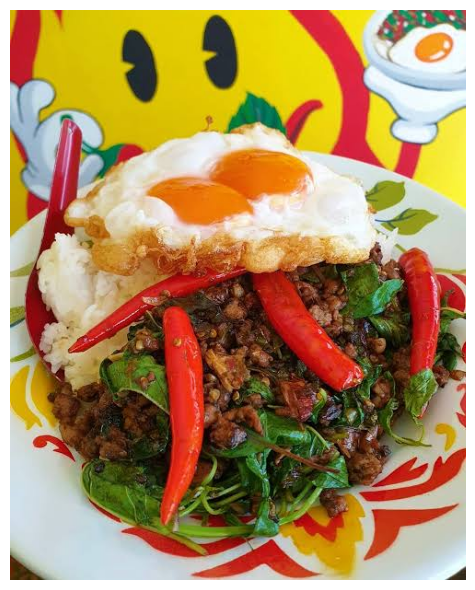

Food: Pad Kra Pao (ผัดกะเพรา)
Class: pad_kra_pao
Confidence: 60.70%
Estimated Calories: ประมาณ 450–750 kcal / 1 จานพร้อมข้าว (ไม่รวมไข่ดาว)


In [23]:
# Fallback ร่วมของ Live Demo และ Presentation Mode: ใช้เมื่อ widget ไม่แสดงเท่านั้น
_demo_result = choose_food_image()


## Final Results Summary — สรุปผลการทดลอง

สรุปนี้อ้างจาก **Outputs ที่บันทึกไว้ใน Notebook** ไม่ใช่ผลจากการรันใหม่

| รายการ | ผลที่บันทึกไว้ |
|---|---|
| Dataset | 646 ภาพ / 5 คลาส |
| Train / Validation / Test | 452 / 99 / 95 ภาพ |
| สัดส่วนข้อมูล | ประมาณ 70 / 15 / 15 |
| โมเดล | MobileNetV2 Transfer Learning; Freeze base และฝึก classification head |
| การฝึก | 10 Epochs; Optional Fine-Tuning ไม่ได้เปิดใช้ |
| เลือก checkpoint | Validation loss ต่ำสุดที่ Epoch 9 = 0.2740 |
| Test Loss | 0.2806 |
| Test Accuracy | 0.905263 ≈ **90.53%** (ถูก 86/95 ภาพ) |
| Precision (Macro) | 0.925287 ≈ **92.53%** |
| Recall (Macro) | 0.902924 ≈ **90.29%** |
| F1-Score (Macro) | 0.906799 ≈ **90.68%** |


**อ่าน Confusion Matrix:** แนวทแยงรวม 86 ภาพจาก 95 ภาพ มีข้อผิดพลาด 9 ภาพ
คู่ผิดมากที่สุดคือผัดกะเพรา → ลาบ 4 ภาพ ทำให้ Recall ของผัดกะเพราเป็น 0.7778
แม้ Recall ของลาบเป็น 1.0000 แต่ Precision ของลาบเป็น 0.7931 เพราะรับภาพคลาสอื่นมาเป็นลาบด้วย
ผลนี้แสดงว่ายังมีความสับสนระหว่างคลาส ไม่ควรสรุปจาก Accuracy อย่างเดียว

**ผลภาพใหม่ที่บันทึกไว้:** ตัวอย่าง JPG ทำนาย `my_food_test.jpg` เป็น Tom Yum / ต้มยำ
Confidence 98.26%; ตัวอย่าง WEBP แล้วทำนายเป็น Larb / ลาบ Confidence 98.44%
สองค่านี้เป็นผล prediction ที่บันทึกไว้ ไม่ใช่ Accuracy หรือการยืนยันว่าอาหารจริงถูกจำแนกเสมอ

**ข้อจำกัด:** Test มี 95 ภาพ และโมเดลรู้จักเพียง 5 คลาส อาหารอื่นหรือภาพที่ไม่ใช่อาหารก็อาจได้ Confidence สูง


## ขั้นตอนสำหรับนำเสนอ / Presentation Checklist

1. เปิด Notebook จากโฟลเดอร์โปรเจกต์ ใช้ local Windows kernel ที่มี dependencies และ `tkinter`
2. ใช้ Outputs เดิมอธิบาย Dataset, Training และ Evaluation; ไม่ลบกราฟหรือรันใหม่
3. Kernel เดิม: รัน Live Demo; หลัง Restart Kernel: รันเฉพาะ Presentation Mode
4. กด **เลือกรูปอาหาร** เลือกภาพใหม่ แล้วอธิบายผล; หาก widget ไม่แสดงใช้เซลล์ fallback ร่วม

เตรียม `task2_food_demo.py` และโมเดลเดิมไว้ข้าง Notebook ซ้อม Cancel และเลือกภาพซ้ำก่อนนำเสนอ
**ไม่กด Run All ไม่รัน preparation/training และไม่เปิด Fine-Tuning**
Environment ที่บันทึกไว้: Python 3.13.5 / TensorFlow 2.21.0 / Keras 3.15.1
